In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [77]:
img1 = cv2.imread('car.jpg')  # 任务一专用图片

# 2. 灰度化：彩色转灰度
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)  # OpenCV默认BGR，使用COLOR_BGR2GRAY

# 3. 截取感兴趣区域ROI（车牌区域：根据实际图像调整坐标）

roi1 = gray1[50:150, 180:400]

# 4. 计算灰度直方图（使用cv2.calcHist）
hist1 = cv2.calcHist([roi1], [0], None, [256], [0, 256])

# 5. 图像平滑去噪：均值滤波
smooth1 = cv2.blur(roi1, (2, 2))  # 3x3滤波核
smooth2 =cv2.blur(roi1,(3,3)) 
smooth3=cv2.blur(roi1,(4,4))
smooth4=cv2.blur(roi1,(5,5))
smooth5=cv2.blur(roi1,(6,6))
smooth6=cv2.blur(roi1,(7,7))
# 6. 计算 平滑滤波后 的直方图（新增！）
hist_smooth = cv2.calcHist([smooth1], [0], None, [256], [0, 256])
# 直方图均衡化
equ1 = cv2.equalizeHist(roi1)
hist_equ = cv2.calcHist([equ1], [0], None, [256], [0, 256])

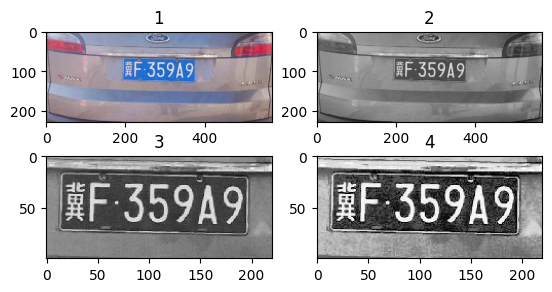

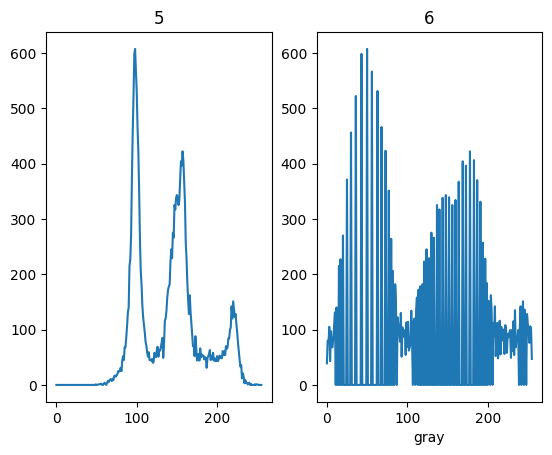

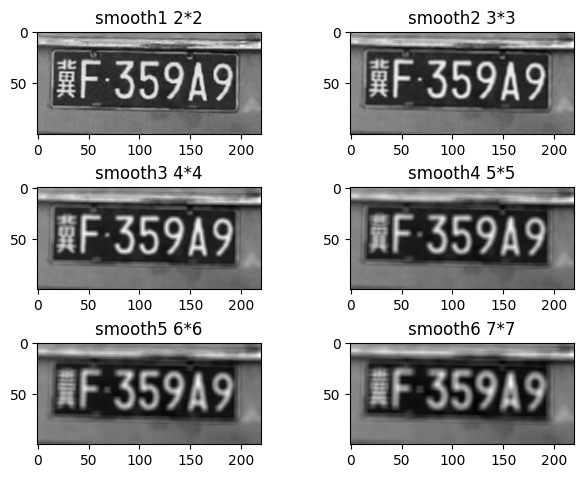

In [87]:
plt.subplot(321), plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)), plt.title('1')
plt.subplot(322), plt.imshow(gray1, cmap='gray'), plt.title('2')
plt.subplot(323), plt.imshow(roi1, cmap='gray'), plt.title('3')
plt.subplot(324), plt.imshow(equ1, cmap='gray'), plt.title('4')
plt.show()
plt.subplot(121),plt.plot(hist1), plt.title('5')
plt.subplot(122),plt.plot(hist_equ),plt.title('6'),plt.xlabel('gray')
plt.show()

plt.subplot(321), plt.imshow(smooth1, cmap='gray'), plt.title('smooth1 2*2')
plt.subplot(322), plt.imshow(smooth2, cmap='gray'), plt.title('smooth2 3*3')
plt.subplot(323), plt.imshow(smooth3, cmap='gray'), plt.title('smooth3 4*4')
plt.subplot(324), plt.imshow(smooth4, cmap='gray'), plt.title('smooth4 5*5')
plt.subplot(325), plt.imshow(smooth5, cmap='gray'), plt.title('smooth5 6*6')
plt.subplot(326), plt.imshow(smooth6, cmap='gray'), plt.title('smooth6 7*7')
plt.tight_layout(pad=1.0)
plt.show()

===== 任务二 PSNR 评估结果 =====
均值滤波(3x3) PSNR：31.39
高斯滤波(3x3) PSNR：32.14
中值滤波(3x3) PSNR：33.73
CLAHE增强 PSNR：28.94
优化CLAHE PSNR：28.28


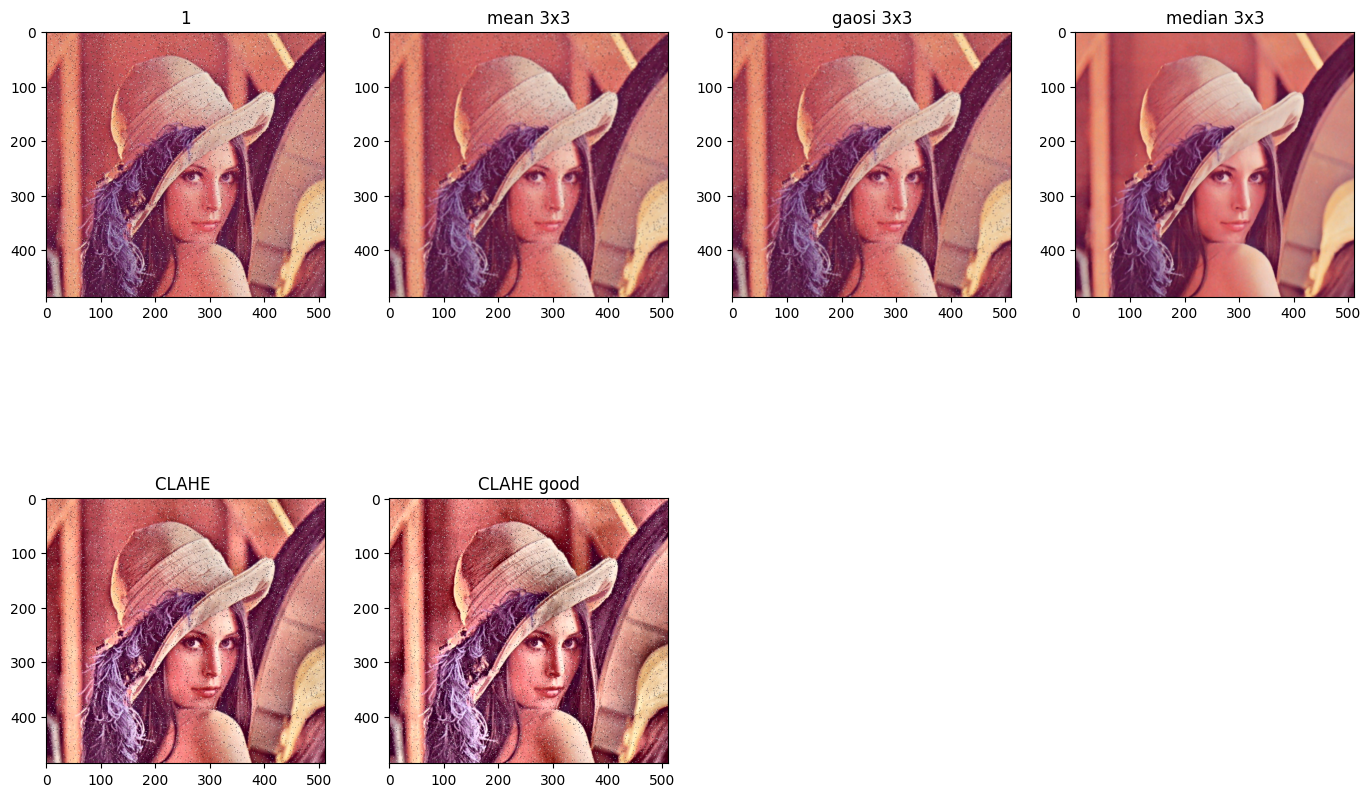

In [79]:

img2 = cv2.imread('girl.jpg')  

# --------------------- 彩色图像滤波 ---------------------
# 均值滤波
mean_blur = cv2.blur(img2, (3, 3))
# 高斯滤波
gaussian_blur = cv2.GaussianBlur(img2, (3, 3), 0)
# 中值滤波
median_blur = cv2.medianBlur(img2, 3)

# --------------------- 彩色图像 CLAHE 增强 ---------------------
# 把 BGR 转 YCrCb（专门用于彩色图像增强）
ycrcb = cv2.cvtColor(img2, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)

# 对亮度通道 Y 做 CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
y_enhanced = clahe.apply(y)

# 合并回去
ycrcb_enhanced = cv2.merge((y_enhanced, cr, cb))
clahe_result = cv2.cvtColor(ycrcb_enhanced, cv2.COLOR_YCrCb2BGR)

# 优化 CLAHE
clahe_opt = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(6,6))
y_enhanced_opt = clahe_opt.apply(y)
ycrcb_enhanced_opt = cv2.merge((y_enhanced_opt, cr, cb))
clahe_opt_result = cv2.cvtColor(ycrcb_enhanced_opt, cv2.COLOR_YCrCb2BGR)

# --------------------- PSNR 计算 ---------------------
def calculate_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

psnr_mean = calculate_psnr(img2, mean_blur)
psnr_gaussian = calculate_psnr(img2, gaussian_blur)
psnr_median = calculate_psnr(img2, median_blur)
psnr_clahe = calculate_psnr(img2, clahe_result)
psnr_clahe_opt = calculate_psnr(img2, clahe_opt_result)

print("===== 任务二 PSNR 评估结果 =====")
print(f"均值滤波(3x3) PSNR：{psnr_mean:.2f}")
print(f"高斯滤波(3x3) PSNR：{psnr_gaussian:.2f}")
print(f"中值滤波(3x3) PSNR：{psnr_median:.2f}")
print(f"CLAHE增强 PSNR：{psnr_clahe:.2f}")
print(f"优化CLAHE PSNR：{psnr_clahe_opt:.2f}")
print("===============================")

# --------------------- 显示（全部彩色！） ---------------------
plt.figure(figsize=(14,10))

plt.subplot(241), plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)), plt.title('1')
plt.subplot(242), plt.imshow(cv2.cvtColor(mean_blur, cv2.COLOR_BGR2RGB)), plt.title('mean 3x3')
plt.subplot(243), plt.imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)), plt.title('gaosi 3x3')
plt.subplot(244), plt.imshow(cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB)), plt.title('median 3x3')
plt.subplot(245), plt.imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB)), plt.title('CLAHE ')
plt.subplot(246), plt.imshow(cv2.cvtColor(clahe_opt_result, cv2.COLOR_BGR2RGB)), plt.title('CLAHE good')

plt.tight_layout(pad=2.0)
plt.show()

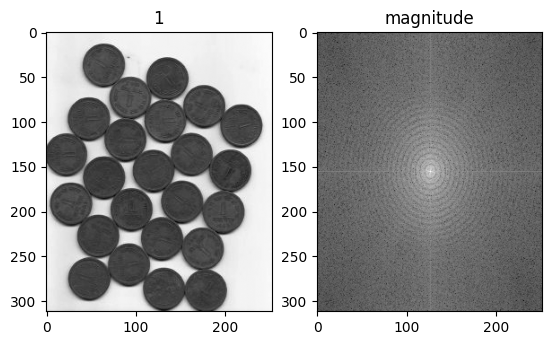

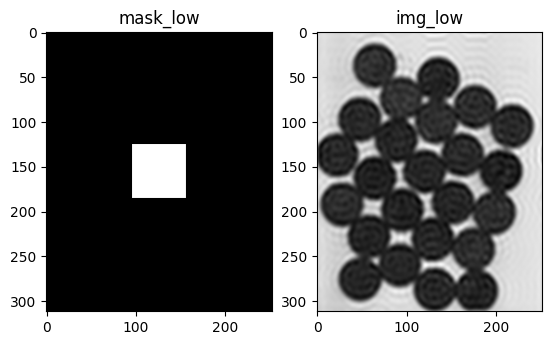

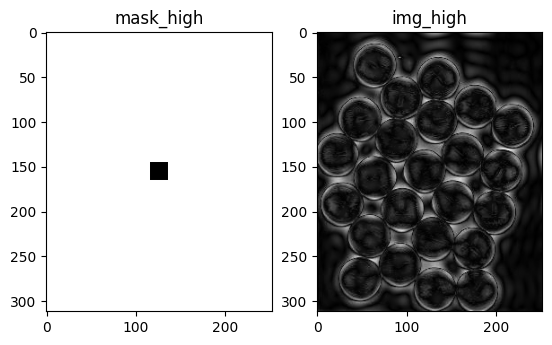

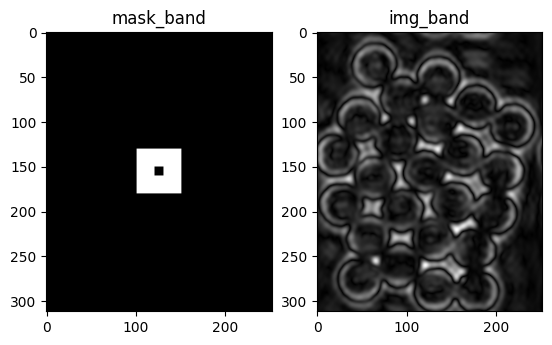

In [86]:

# 读取灰度图像
img3 = cv2.imread('money.jpg', 0)  # 直接读取灰度图

# 离散傅里叶变换
dft = cv2.dft(np.float32(img3), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)  # 低频移到中心

# 计算幅度谱（方便观察）
magnitude = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))


rows, cols = img3.shape
crow, ccol = rows // 2, cols // 2  # 频谱中心点

# 低通滤波器（去噪、模糊）
mask_low = np.zeros((rows, cols, 2), np.uint8)
mask_low[crow-30:crow+30, ccol-30:ccol+30] = 1  # 保留中心低频

# 滤波 + 逆变换
fshift_low = dft_shift * mask_low
f_ishift_low = np.fft.ifftshift(fshift_low)
img_low = cv2.idft(f_ishift_low)
img_low = cv2.magnitude(img_low[:,:,0], img_low[:,:,1])

#  高通滤波器（锐化、边缘提取）
mask_high = np.ones((rows, cols, 2), np.uint8)
mask_high[crow-10:crow+10, ccol-10:ccol+10] = 0  # 去掉中心低频

# 滤波 + 逆变换
fshift_high = dft_shift * mask_high
f_ishift_high = np.fft.ifftshift(fshift_high)
img_high = cv2.idft(f_ishift_high)
img_high = cv2.magnitude(img_high[:,:,0], img_high[:,:,1])

#  带通滤波器（保留部分细节） 
mask_band = np.zeros((rows, cols, 2), np.uint8)
mask_band[crow-25:crow+25, ccol-25:ccol+25] = 1
mask_band[crow-5:crow+5, ccol-5:ccol+5] = 0

# 滤波 + 逆变换
fshift_band = dft_shift * mask_band
f_ishift_band = np.fft.ifftshift(fshift_band)
img_band = cv2.idft(f_ishift_band)
img_band = cv2.magnitude(img_band[:,:,0], img_band[:,:,1])

# 结果显示 

# 原图 + 幅度谱
plt.subplot(121), plt.imshow(img3, cmap='gray'), plt.title('1')
plt.subplot(122), plt.imshow(magnitude, cmap='gray'), plt.title('magnitude')
plt.show()
# 低通滤波
plt.subplot(121), plt.imshow(mask_low[:,:,0], cmap='gray'), plt.title('mask_low')
plt.subplot(122), plt.imshow(img_low, cmap='gray'), plt.title('img_low')
plt.show()
# 高通滤波
plt.subplot(121), plt.imshow(mask_high[:,:,0], cmap='gray'), plt.title('mask_high')
plt.subplot(122), plt.imshow(img_high, cmap='gray'), plt.title('img_high')
plt.show()
# 带通滤波
plt.subplot(121), plt.imshow(mask_band[:,:,0], cmap='gray'), plt.title('mask_band')
plt.subplot(122), plt.imshow(img_band, cmap='gray'), plt.title('img_band')
plt.show()